In [22]:
from mp_api.client import MPRester

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with MPRester() as mpr:
    silicon = mpr.materials.summary.search(
        material_ids=["mp-149"],
        fields=["material_id", "formula_pretty", "band_gap"]
    )

print(silicon)

Retrieving SummaryDoc documents: 100%|██████████| 1/1 [00:00<00:00, 15420.24it/s]

[MPDataDoc<SummaryDoc>(
band_gap=0.6102999999999996,
formula_pretty='Si',
material_id=MPID(mp-149),
fields_not_requested=['builder_meta', 'nsites', 'elements', 'nelements', 'composition', 'composition_reduced', 'formula_anonymous', 'chemsys', 'volume', 'density', 'density_atomic', 'symmetry', 'deprecated', 'deprecation_reasons', 'last_updated', 'origins', 'warnings', 'structure', 'property_name', 'task_ids', 'uncorrected_energy_per_atom', 'energy_per_atom', 'formation_energy_per_atom', 'energy_above_hull', 'is_stable', 'equilibrium_reaction_energy_per_atom', 'decomposes_to', 'xas', 'grain_boundaries', 'cbm', 'vbm', 'efermi', 'is_gap_direct', 'is_metal', 'es_source_calc_id', 'bandstructure', 'dos', 'dos_energy_up', 'dos_energy_down', 'is_magnetic', 'ordering', 'total_magnetization', 'total_magnetization_normalized_vol', 'total_magnetization_normalized_formula_units', 'num_magnetic_sites', 'num_unique_magnetic_sites', 'types_of_magnetic_species', 'bulk_modulus', 'shear_modulus', 'univers

In [3]:
fields = [
    "material_id",
    "formula_pretty",
    "composition",
    "nelements",
    "band_gap",
    "is_gap_direct",
    "is_metal",
    "energy_above_hull",
    "is_stable",
    "formation_energy_per_atom",
    "density",
    "symmetry",
    "theoretical"
]

with MPRester() as mpr:
    docs = mpr.materials.summary.search(
        band_gap=(0.1, 5.0),
        fields=fields
    )

print(f"Retrieved {len(docs)} materials")

Retrieving SummaryDoc documents: 100%|██████████| 72570/72570 [00:16<00:00, 4398.12it/s]

Retrieved 72570 materials


In [12]:
data = []

for material in docs:
    data.append({
        "material_id": str(material.material_id),
        "formula": material.formula_pretty,
        "band_gap": material.band_gap,
        "is_gap_direct": material.is_gap_direct,
        "is_metal": material.is_metal,
        "energy_above_hull": material.energy_above_hull,
        "is_stable": material.is_stable,
        "formation_energy_per_atom": material.formation_energy_per_atom,
        "density": material.density,
        "nelements": material.nelements,
        "theoretical": material.theoretical
    })

df = pd.DataFrame(data)

df.head(10)

,material_id,formula,band_gap,is_gap_direct,is_metal,energy_above_hull,is_stable,formation_energy_per_atom,density,nelements,theoretical
0,mp-11107,Ac2O3,3.5219,False,False,0.000000,True,-3.737668,9.109130,2,False
1,mp-32800,Ac2S3,2.2729,False,False,0.000000,True,-2.493064,6.535149,2,True
2,mp-977351,Ac2S3,3.0275,False,False,0.052700,False,-2.440364,5.562971,2,True
3,mp-1183115,AcAlO3,4.1024,True,False,0.000000,True,-3.690019,8.728230,3,True
4,mp-1183052,AcBO3,0.8071,False,False,0.792473,False,-2.475390,9.206879,3,True
5,mp-27972,AcBr3,4.1034,False,False,0.000000,True,-2.494519,5.679086,2,False
6,mp-30274,AcBrO,4.2407,True,False,0.000000,True,-3.218186,7.652290,3,False
7,mp-30273,AcClO,4.4457,False,False,0.001680,False,-3.381758,7.156871,3,False
8,mp-866101,AcCrO3,2.0031,False,False,0.000000,True,-3.138972,8.848788,3,True
9,mp-861502,AcFeO3,1.0084,False,False,0.000000,True,-2.771539,8.889999,3,True


In [20]:
df.shape, df.info(), df.describe(), df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 72570 entries, 0 to 72569
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   material_id                72570 non-null  str    
 1   formula                    72570 non-null  str    
 2   band_gap                   72570 non-null  float64
 3   is_gap_direct              72570 non-null  bool   
 4   is_metal                   72532 non-null  object 
 5   energy_above_hull          72570 non-null  float64
 6   is_stable                  72570 non-null  bool   
 7   formation_energy_per_atom  72570 non-null  float64
 8   density                    72570 non-null  float64
 9   nelements                  72570 non-null  int64  
 10  theoretical                72570 non-null  bool   
dtypes: bool(3), float64(4), int64(1), object(1), str(2)
memory usage: 4.6+ MB


((72570, 11),
 None,
            band_gap  energy_above_hull  formation_energy_per_atom  \
 count  72570.000000       72570.000000               72570.000000   
 mean       1.939021           0.119748                  -1.965557   
 std        1.279530           0.284304                   0.971074   
 min        0.100000           0.000000                  -4.389466   
 25%        0.834900           0.004735                  -2.637854   
 50%        1.771300           0.046145                  -2.151335   
 75%        2.890800           0.113640                  -1.381507   
 max        4.999900           5.536308                   5.090896   
 
             density     nelements  
 count  72570.000000  72570.000000  
 mean       4.097967      3.822089  
 std        1.659019      0.988503  
 min        0.020144      1.000000  
 25%        2.952627      3.000000  
 50%        3.815016      4.000000  
 75%        5.001920      4.000000  
 max       16.321559      9.000000  ,
 material_id 

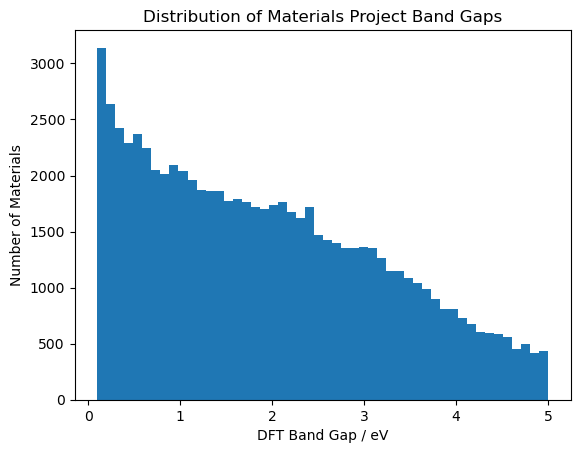

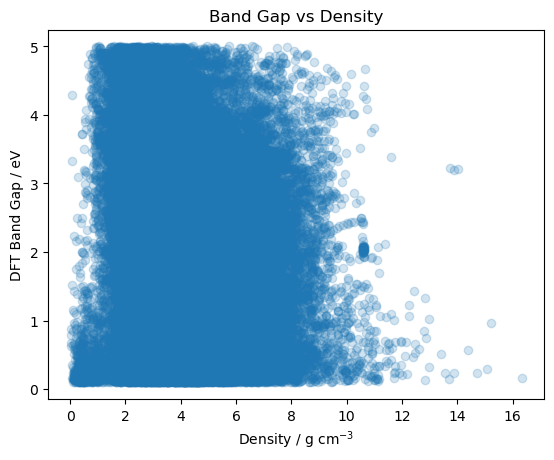

In [24]:
plt.hist(df["band_gap"], bins=50)
plt.xlabel("DFT Band Gap / eV")
plt.ylabel("Number of Materials")
plt.title("Distribution of Materials Project Band Gaps")
plt.show()

plt.scatter(
    df["density"],
    df["band_gap"],
    alpha=0.2
)

plt.xlabel("Density / g cm$^{-3}$")
plt.ylabel("DFT Band Gap / eV")
plt.title("Band Gap vs Density")
plt.show()